In [13]:
import time

start = time.time()

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

end = time.time()

print(f"Import time: {str(end - start)}")

Import time: 0.0006814002990722656


## Задание 1
Изобразить гистограмму, которая показывает баланс классов. Сделать выводы.

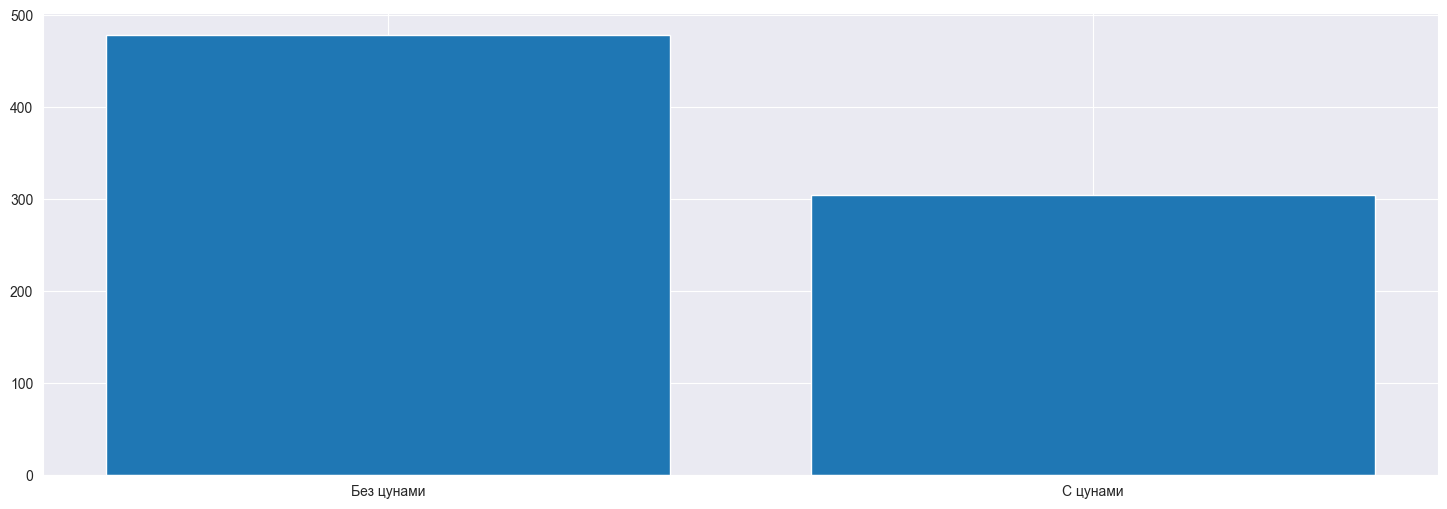

In [14]:
data = pd.read_csv('PR5/earthquake_data_tsunami.csv', sep=',')

plt.figure(figsize=(18, 6))

class_counts = data['tsunami'].value_counts()
class_labels = ['Без цунами', 'С цунами']

plt.bar(class_labels, class_counts.values)
plt.show()

## Задание 2
Разбить выборку на тренировочную и тестовую. Тренировочная для обучения модели, тестовая для проверки ее качества.

In [15]:
data = pd.read_csv('PR5/earthquake_data_tsunami.csv', sep=',')

print("Столбцы в датасете:", data.columns.tolist())

predictors = data.drop(columns=["tsunami"])

target = data["tsunami"]

x_train, x_test, y_train, y_test = train_test_split(
    predictors,
    target,
    train_size=0.8,
    shuffle=True,
    random_state=271
)

print("Размер для признаков обучающей выборки:", x_train.shape, '\n',
      "Размер для признаков тестовой выборки:", x_test.shape, '\n',
      "Размер для целевого показателя обучающей выборки:", y_train.shape, '\n',
      "Размер для показателя тестовой выборки:", y_test.shape)

Столбцы в датасете: ['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth', 'latitude', 'longitude', 'Year', 'Month', 'tsunami']
Размер для признаков обучающей выборки: (625, 12) 
 Размер для признаков тестовой выборки: (157, 12) 
 Размер для целевого показателя обучающей выборки: (625,) 
 Размер для показателя тестовой выборки: (157,)


## Задание 3
Применить алгоритмы классификации: логистическая регрессия, SVM, KNN. Построить матрицу ошибок по результатам работы моделей (использовать confusion_matrix из sklearn.metrics).

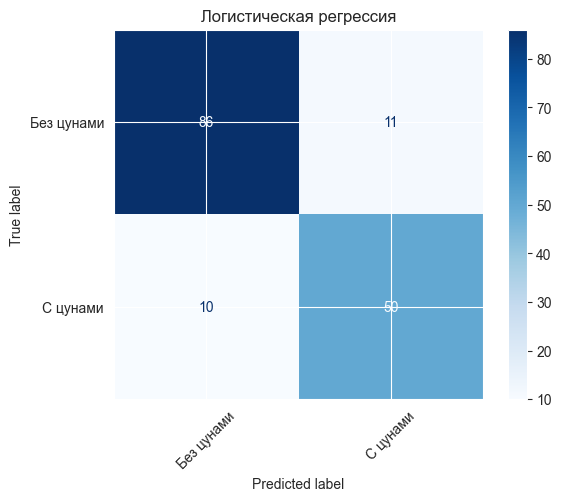

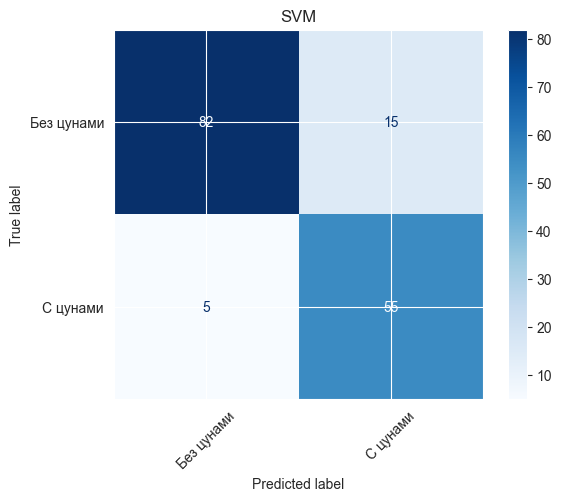

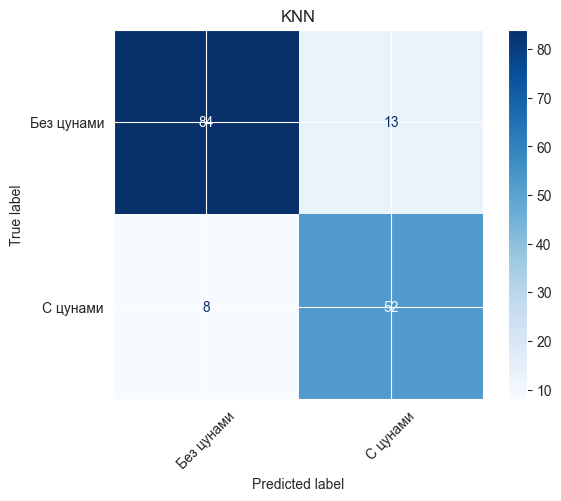

In [16]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

models = {
    "Логистическая регрессия": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

variable = []

for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)

    variable.append(y_pred)

    unique_labels = np.unique(np.concatenate((y_test, y_pred)))

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Без цунами', 'С цунами'])
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"{name}")
    plt.show()


## Задание 4
Сравнить результаты классификации, используя accuracy, precision, recall и f1-меру (можно использовать classification_report из sklearn.metrics). Сделать выводы.

In [18]:
print("Logistic Regression\n", classification_report(y_test, variable[0]))
print("SVM\n", classification_report(y_test, variable[1]))
print("KNN\n", classification_report(y_test, variable[2]))

Logistic Regression
               precision    recall  f1-score   support

           0       0.90      0.89      0.89        97
           1       0.82      0.83      0.83        60

    accuracy                           0.87       157
   macro avg       0.86      0.86      0.86       157
weighted avg       0.87      0.87      0.87       157

SVM
               precision    recall  f1-score   support

           0       0.94      0.85      0.89        97
           1       0.79      0.92      0.85        60

    accuracy                           0.87       157
   macro avg       0.86      0.88      0.87       157
weighted avg       0.88      0.87      0.87       157

KNN
               precision    recall  f1-score   support

           0       0.91      0.87      0.89        97
           1       0.80      0.87      0.83        60

    accuracy                           0.87       157
   macro avg       0.86      0.87      0.86       157
weighted avg       0.87      0.87      0.87